# Lab Report — Lab 5

| | |
|---|---|
| **Course** | Digital Signal Processing |
| **Teacher** | prof. dr hab. Vasyl Martsenyuk, dr inż. Halyna Nahorniak |
| **Date** | 27.03.2026 |
| **Topic** | Random Signal Analysis. Power Spectrum Estimation |
| **Student** | Jakub Kołodziej |
| **Variant** | 11 |

---

## 1. Problem Statement

This report covers two tasks in the field of random signal analysis and power spectrum estimation:

**Task A — AR(2) Process Generation and Autocorrelation Analysis (Variant 11):**  
Generate an AR(2) process using predefined coefficients (a₁ = −1.5, a₂ = 0.7). Analyze the signal's autocorrelation function and compare it against the theoretical ACF derived from the Yule–Walker equations.

**Task B — Parametric PSD Estimation (Variant 11):**  
Estimate the Power Spectral Density using the parametric AR (Yule–Walker) method. Compare the estimated PSD with the theoretical PSD computed from the true model coefficients, and with a non-parametric Welch estimate.

---

## 2. Input Data

### Task A — AR(2) Process Generation

| Parameter | Value |
|---|---|
| AR model order | 2 |
| Coefficient a₁ (x[n−1]) | −1.5 |
| Coefficient a₂ (x[n−2]) | 0.7 |
| Signal length N | 2000 samples |
| Sampling frequency fₛ | 1000 Hz |
| Driving noise std σ_w | 1.0 |
| Random seed | 42 |

The AR(2) model is defined as:

$$x[n] + a_1 x[n-1] + a_2 x[n-2] = w[n]$$

i.e. $x[n] = 1.5\,x[n-1] - 0.7\,x[n-2] + w[n]$, where $w[n] \sim \mathcal{N}(0, \sigma_w^2)$.

### Task B — PSD Estimation

| Parameter | Value |
|---|---|
| AR order for estimation | 2 (true order) |
| Estimation method | Yule–Walker |
| NFFT (frequency resolution) | 1024 |
| Welch segment length | 256 |
| Welch overlap | 128 |
| Welch window | Hann |

---

## 3. Implementation

### Theoretical Background

**AR(2) model:**  
An autoregressive process of order 2 satisfies $x[n] + a_1 x[n-1] + a_2 x[n-2] = w[n]$.
Stability requires that both poles lie inside the unit circle.  
For $a_1 = -1.5$, $a_2 = 0.7$, the poles are complex conjugates at $|z| = \sqrt{a_2} \approx 0.837 < 1$ — stable.

**Theoretical autocorrelation (Yule–Walker):**  
For lags $k \geq 1$: $\rho(k) + a_1\rho(k-1) + a_2\rho(k-2) = 0$  
with initial conditions: $\rho(0) = 1$, $\rho(1) = \dfrac{-a_1}{1 + a_2}$

**Theoretical PSD (AR model):**  
$$S(f) = \frac{\sigma_w^2}{\left|1 + a_1 e^{-j2\pi f/f_s} + a_2 e^{-j4\pi f/f_s}\right|^2}$$

### Task A — AR(2) Signal Generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, correlate, welch, periodogram
from numpy.linalg import solve

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
np.random.seed(42)

N = 2000
fs = 1000
sigma_w = 1.0

a1 = -1.5
a2 = 0.7
a = [1, a1, a2]
b = [1]

poles = np.roots(a)
stable = all(np.abs(poles) < 1)
resonant_freq = np.angle(poles[0]) / (2 * np.pi) * fs

print("=" * 50)
print("AR(2) MODEL — VARIANT 11")
print("=" * 50)
print(f"  Coefficients : a1 = {a1}, a2 = {a2}")
print(f"  Model        : x[n] = 1.5*x[n-1] - 0.7*x[n-2] + w[n]")
print(f"  Poles        : {poles[0]:.4f}, {poles[1]:.4f}")
print(f"  Pole moduli  : |z1| = {abs(poles[0]):.4f}, |z2| = {abs(poles[1]):.4f}")
print(
    f"  Stable       : {'YES — all poles inside unit circle' if stable else 'NO — unstable process!'}"
)
print(f"  Resonant frequency ≈ {resonant_freq:.1f} Hz  (at fs = {fs} Hz)")
print("=" * 50)

AR(2) MODEL — VARIANT 11
  Coefficients : a1 = -1.5, a2 = 0.7
  Model        : x[n] = 1.5*x[n-1] - 0.7*x[n-2] + w[n]
  Poles        : 0.7500+0.3708j, 0.7500-0.3708j
  Pole moduli  : |z1| = 0.8367, |z2| = 0.8367
  Stable       : YES — all poles inside unit circle
  Resonant frequency ≈ 73.1 Hz  (at fs = 1000 Hz)


Signal length   : N = 2000 samples (2.00 s at fs=1000 Hz)
Estimated mean  : 0.2294  (expected: 0.0)
Estimated var   : 8.5721
Estimated std   : 2.9278
Min / Max       : -8.305 / 10.560


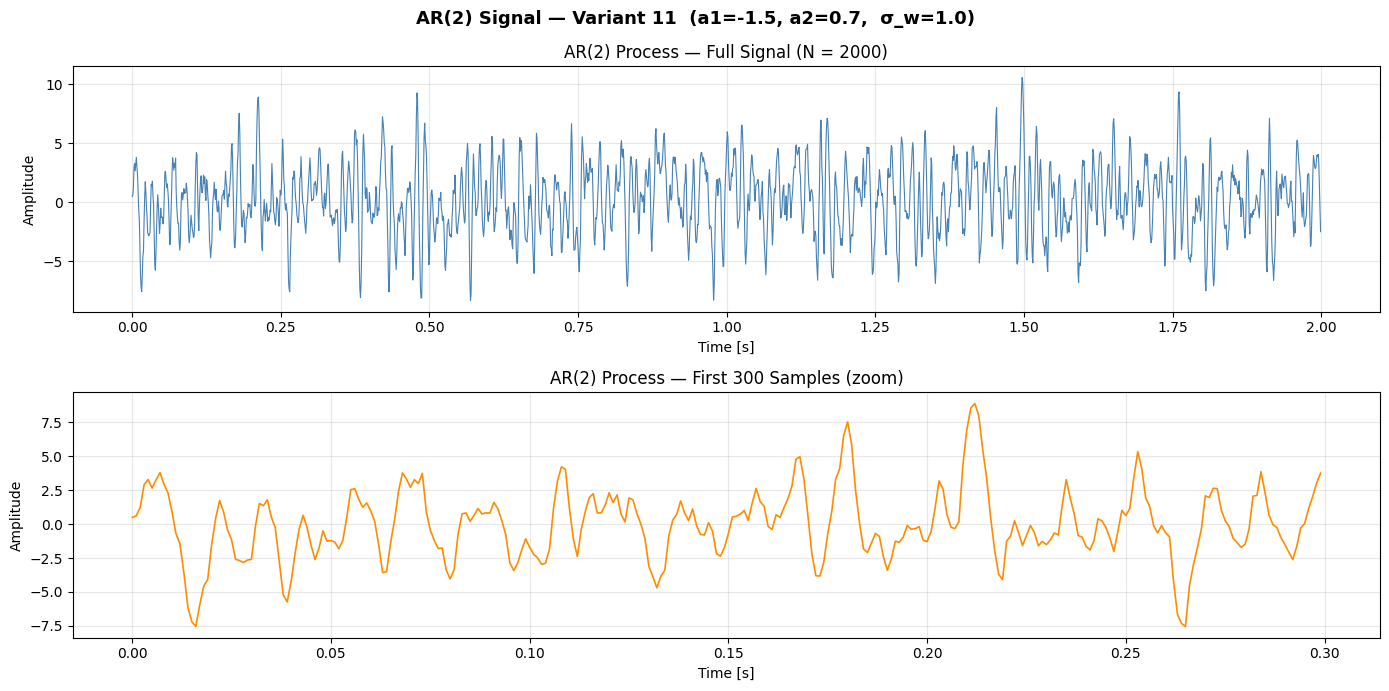

In [3]:
w_noise = np.random.normal(0, sigma_w, N)
x = lfilter(b, a, w_noise)
t = np.arange(N) / fs

print(f"Signal length   : N = {N} samples ({N/fs:.2f} s at fs={fs} Hz)")
print(f"Estimated mean  : {np.mean(x):.4f}  (expected: 0.0)")
print(f"Estimated var   : {np.var(x):.4f}")
print(f"Estimated std   : {np.std(x):.4f}")
print(f"Min / Max       : {x.min():.3f} / {x.max():.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(t, x, color="steelblue", lw=0.8)
axes[0].set_title("AR(2) Process — Full Signal (N = 2000)", fontsize=12)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[:300], x[:300], color="darkorange", lw=1.2)
axes[1].set_title("AR(2) Process — First 300 Samples (zoom)", fontsize=12)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f"AR(2) Signal — Variant 11  (a1={a1}, a2={a2},  σ_w={sigma_w})",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### Task A — Autocorrelation Analysis

Theoretical rho(1) = 0.8824
Estimated    rho(1) = 0.8806
RMSE (estimated vs theoretical ACF) = 0.0369


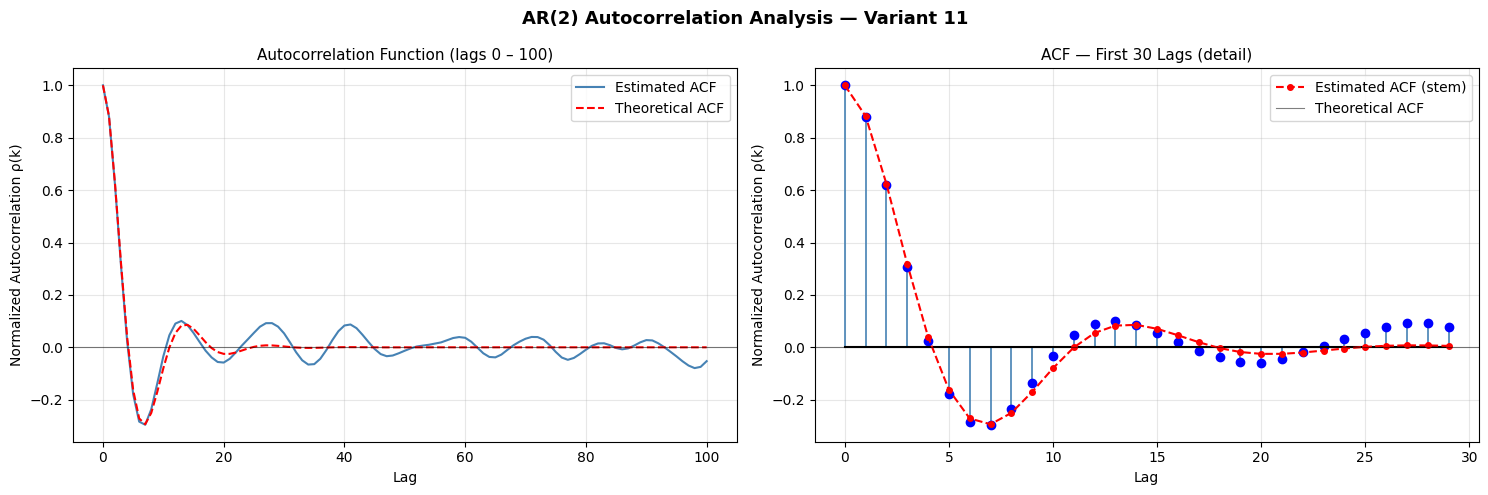

In [4]:
MAX_LAG = 100

full_corr = correlate(x, x, mode="full")
r_est = full_corr[full_corr.size // 2 : full_corr.size // 2 + MAX_LAG + 1]
r_est = r_est / r_est[0]

rho_theory = np.zeros(MAX_LAG + 1)
rho_theory[0] = 1.0
rho_theory[1] = -a1 / (1 + a2)
for k in range(2, MAX_LAG + 1):
    rho_theory[k] = -a1 * rho_theory[k - 1] - a2 * rho_theory[k - 2]

lags = np.arange(MAX_LAG + 1)
rmse_acf = np.sqrt(np.mean((r_est - rho_theory) ** 2))

print(f"Theoretical rho(1) = {rho_theory[1]:.4f}")
print(f"Estimated    rho(1) = {r_est[1]:.4f}")
print(f"RMSE (estimated vs theoretical ACF) = {rmse_acf:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(lags, r_est, color="steelblue", lw=1.5, label="Estimated ACF")
axes[0].plot(
    lags, rho_theory, color="red", lw=1.5, linestyle="--", label="Theoretical ACF"
)
axes[0].axhline(0, color="black", lw=0.8, alpha=0.5)
axes[0].set_title("Autocorrelation Function (lags 0 – 100)", fontsize=11)
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Normalized Autocorrelation ρ(k)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

markerline, stemlines, baseline = axes[1].stem(
    lags[:30], r_est[:30], linefmt="steelblue", markerfmt="bo", basefmt="k-"
)
plt.setp(stemlines, linewidth=1.2)
axes[1].plot(
    lags[:30], rho_theory[:30], "r--o", lw=1.5, markersize=4, label="Theoretical ACF"
)
axes[1].axhline(0, color="black", lw=0.8, alpha=0.5)
axes[1].set_title("ACF — First 30 Lags (detail)", fontsize=11)
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Normalized Autocorrelation ρ(k)")
axes[1].legend(["Estimated ACF (stem)", "Theoretical ACF"])
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "AR(2) Autocorrelation Analysis — Variant 11", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### Results — Task A

In [5]:
selected_lags = [0, 1, 2, 3, 5, 10, 20, 50, 100]

print("=" * 55)
print("RESULTS — TASK A (AR(2) Autocorrelation, Variant 11)")
print(f"  Model: x[n] = {-a1}*x[n-1] + {-a2}*x[n-2] + w[n]")
print("=" * 55)
print(f"{'Lag':>6} | {'Estimated ρ(k)':>15} | {'Theoretical ρ(k)':>17} | {'Error':>10}")
print("-" * 55)
for k in selected_lags:
    err = abs(r_est[k] - rho_theory[k])
    print(f"{k:>6} | {r_est[k]:>15.4f} | {rho_theory[k]:>17.4f} | {err:>10.4f}")
print("=" * 55)
print(f"  Overall RMSE = {rmse_acf:.4f}")
print("=" * 55)

RESULTS — TASK A (AR(2) Autocorrelation, Variant 11)
  Model: x[n] = 1.5*x[n-1] + -0.7*x[n-2] + w[n]
   Lag |  Estimated ρ(k) |  Theoretical ρ(k) |      Error
-------------------------------------------------------
     0 |          1.0000 |            1.0000 |     0.0000
     1 |          0.8806 |            0.8824 |     0.0017
     2 |          0.6183 |            0.6235 |     0.0053
     3 |          0.3074 |            0.3176 |     0.0103
     5 |         -0.1788 |           -0.1624 |     0.0164
    10 |         -0.0342 |           -0.0798 |     0.0456
    20 |         -0.0582 |           -0.0250 |     0.0332
    50 |         -0.0129 |           -0.0001 |     0.0128
   100 |         -0.0528 |           -0.0000 |     0.0528
  Overall RMSE = 0.0369


---

### Task B — Parametric PSD Estimation (AR / Yule–Walker)

In [6]:
def yule_walker(x, order):
    N = len(x)
    r = np.array(
        [np.correlate(x, x, mode="full")[N - 1 + k] / N for k in range(order + 1)]
    )
    idx = np.arange(order)
    R = r[np.abs(idx[:, None] - idx[None, :])]
    a_hat = solve(R, -r[1 : order + 1])
    sigma2 = r[0] + np.dot(a_hat, r[1 : order + 1])
    return a_hat, float(sigma2)


def ar_psd(a_coeffs, sigma2, freqs, fs):
    omega = 2 * np.pi * freqs / fs
    denom = np.ones(len(omega), dtype=complex)
    for k, ak in enumerate(a_coeffs, start=1):
        denom += ak * np.exp(-1j * k * omega)
    return sigma2 / np.abs(denom) ** 2


AR_ORDER = 2
a_est, sigma2_est = yule_walker(x, AR_ORDER)

print("=" * 55)
print("AR MODEL COEFFICIENT ESTIMATION (Yule–Walker)")
print("=" * 55)
print(f"  True coefficients : a1 = {a1},  a2 = {a2}")
print(f"  Estimated         : a1 = {a_est[0]:.4f}, a2 = {a_est[1]:.4f}")
print(f"  Error Δa1 = {abs(a_est[0] - a1):.4f},  Δa2 = {abs(a_est[1] - a2):.4f}")
print()
print(f"  True noise var σ²_w     = {sigma_w**2:.4f}")
print(f"  Estimated noise var σ²  = {sigma2_est:.4f}")
print("=" * 55)

AR MODEL COEFFICIENT ESTIMATION (Yule–Walker)
  True coefficients : a1 = -1.5,  a2 = 0.7
  Estimated         : a1 = -1.4977, a2 = 0.7006
  Error Δa1 = 0.0023,  Δa2 = 0.0006

  True noise var σ²_w     = 1.0000
  Estimated noise var σ²  = 0.9856


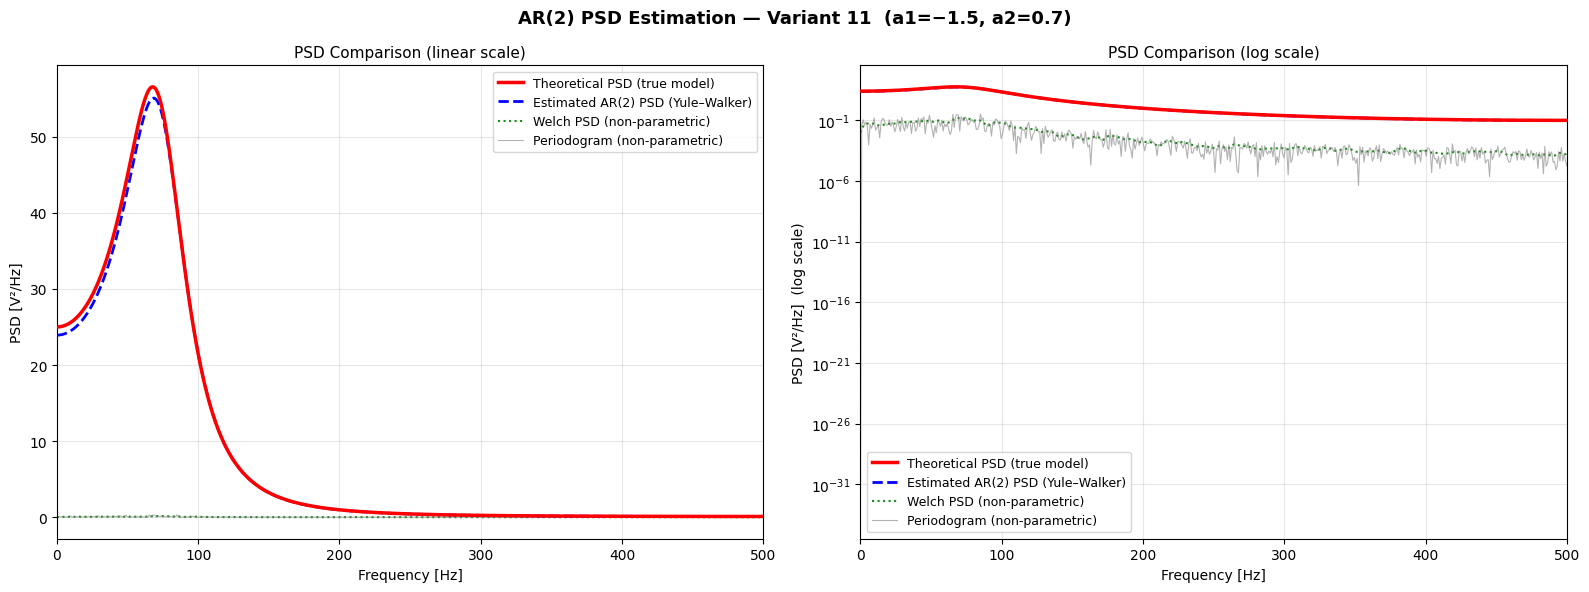

In [7]:
NFFT = 1024
freqs = np.fft.rfftfreq(NFFT, d=1.0 / fs)

psd_theory = ar_psd([a1, a2], sigma_w**2, freqs, fs)
psd_ar_est = ar_psd(a_est, sigma2_est, freqs, fs)

f_welch, psd_welch = welch(
    x, fs=fs, nperseg=256, noverlap=128, window="hann", nfft=NFFT
)

f_pgram, psd_pgram = periodogram(x, fs=fs, nfft=NFFT, window="boxcar")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, scale in zip(axes, ["linear", "log"]):
    ax.plot(
        freqs, psd_theory, "r-", lw=2.5, zorder=5, label="Theoretical PSD (true model)"
    )
    ax.plot(
        freqs,
        psd_ar_est,
        "b--",
        lw=2.0,
        zorder=4,
        label=f"Estimated AR({AR_ORDER}) PSD (Yule–Walker)",
    )
    ax.plot(
        f_welch, psd_welch, "g:", lw=1.5, alpha=0.9, label="Welch PSD (non-parametric)"
    )
    ax.plot(
        f_pgram,
        psd_pgram,
        color="gray",
        lw=0.8,
        alpha=0.6,
        label="Periodogram (non-parametric)",
    )

    if scale == "log":
        ax.set_yscale("log")
        ax.set_title("PSD Comparison (log scale)", fontsize=11)
        ax.set_ylabel("PSD [V²/Hz]  (log scale)")
    else:
        ax.set_title("PSD Comparison (linear scale)", fontsize=11)
        ax.set_ylabel("PSD [V²/Hz]")

    ax.set_xlabel("Frequency [Hz]")
    ax.set_xlim([0, fs / 2])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "AR(2) PSD Estimation — Variant 11  (a1=−1.5, a2=0.7)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

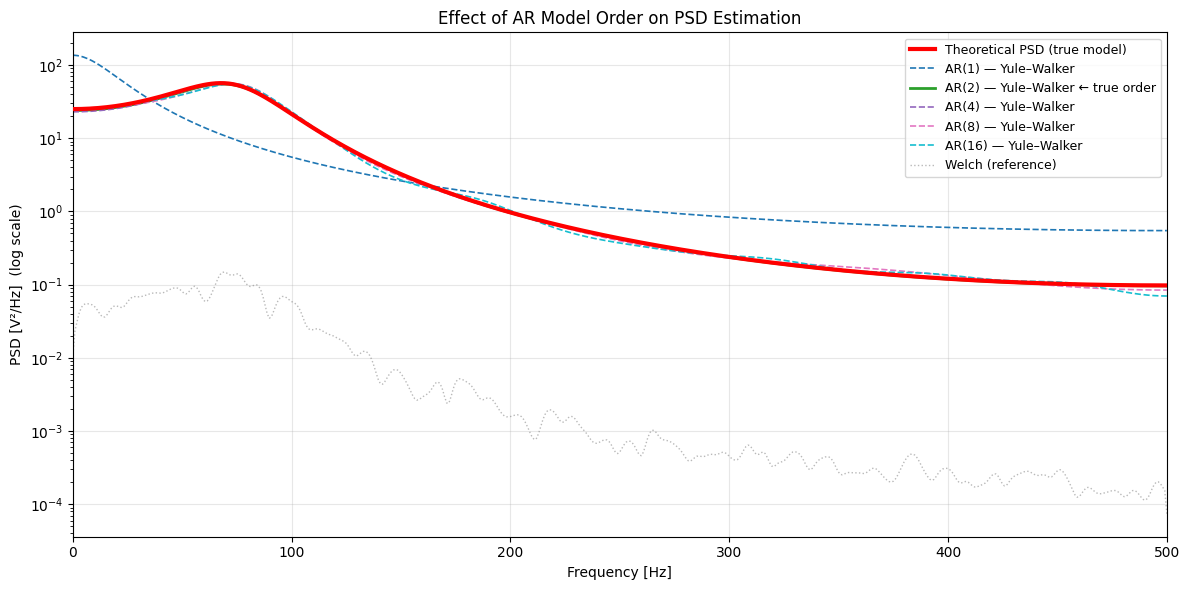

In [8]:
orders = [1, 2, 4, 8, 16]
cmap = plt.cm.tab10(np.linspace(0, 0.9, len(orders)))

plt.figure(figsize=(12, 6))
plt.semilogy(
    freqs, psd_theory, "r-", lw=3, zorder=10, label="Theoretical PSD (true model)"
)

for order, color in zip(orders, cmap):
    a_o, s2_o = yule_walker(x, order)
    psd_o = ar_psd(a_o, s2_o, freqs, fs)
    lw = 2.0 if order == AR_ORDER else 1.2
    ls = "-" if order == AR_ORDER else "--"
    plt.semilogy(
        freqs,
        psd_o,
        linestyle=ls,
        color=color,
        lw=lw,
        label=f"AR({order}) — Yule–Walker"
        + (" ← true order" if order == AR_ORDER else ""),
    )

plt.semilogy(
    f_welch,
    psd_welch,
    color="gray",
    lw=1.0,
    alpha=0.55,
    linestyle=":",
    label="Welch (reference)",
)

plt.title("Effect of AR Model Order on PSD Estimation", fontsize=12)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V²/Hz]  (log scale)")
plt.xlim([0, fs / 2])
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Results — Task B

In [9]:
peak_idx_theory = np.argmax(psd_theory)
peak_idx_est = np.argmax(psd_ar_est)
peak_idx_welch = np.argmax(psd_welch)

print("=" * 65)
print("RESULTS — TASK B (PSD Estimation, Variant 11)")
print(f"  AR model: a1={a1}, a2={a2}")
print("=" * 65)
print(f"{'Method':<35} | {'Peak freq [Hz]':>14} | {'Peak PSD':>12}")
print("-" * 65)
print(
    f"{'Theoretical (true model)':<35} | {freqs[peak_idx_theory]:>14.1f} | {psd_theory[peak_idx_theory]:>12.4f}"
)
print(
    f"{'Estimated AR(2) — Yule–Walker':<35} | {freqs[peak_idx_est]:>14.1f} | {psd_ar_est[peak_idx_est]:>12.4f}"
)
print(
    f"{'Welch (non-parametric)':<35} | {f_welch[peak_idx_welch]:>14.1f} | {psd_welch[peak_idx_welch]:>12.4f}"
)
print("=" * 65)

power_theory = np.trapezoid(psd_theory, freqs)
power_est = np.trapezoid(psd_ar_est, freqs)
power_welch = np.trapezoid(psd_welch, f_welch)

print()
print(f"Total power (integrated PSD):")
print(f"  Theoretical    = {power_theory:.4f}")
print(
    f"  AR(2) estimate = {power_est:.4f}  (error: {abs(power_est - power_theory)/power_theory*100:.2f}%)"
)
print(f"  Welch estimate = {power_welch:.4f}")
print(f"  Signal variance (direct) = {np.var(x):.4f}")
print("=" * 65)

psd_welch_interp = np.interp(freqs, f_welch, psd_welch)
rmse_ar = np.sqrt(np.mean((psd_ar_est - psd_theory) ** 2))
rmse_welch = np.sqrt(np.mean((psd_welch_interp - psd_theory) ** 2))

print()
print(f"RMSE vs. theoretical PSD:")
print(f"  AR(2) Yule–Walker : {rmse_ar:.4f}")
print(f"  Welch             : {rmse_welch:.4f}")
print("=" * 65)

RESULTS — TASK B (PSD Estimation, Variant 11)
  AR model: a1=-1.5, a2=0.7
Method                              | Peak freq [Hz] |     Peak PSD
-----------------------------------------------------------------
Theoretical (true model)            |           67.4 |      56.5568
Estimated AR(2) — Yule–Walker       |           68.4 |      55.0794
Welch (non-parametric)              |           69.3 |       0.1488

Total power (integrated PSD):
  Theoretical    = 4427.0833
  AR(2) estimate = 4312.3594  (error: 2.59%)
  Welch estimate = 8.7756
  Signal variance (direct) = 8.5721

RMSE vs. theoretical PSD:
  AR(2) Yule–Walker : 0.5884
  Welch             : 18.0275


---

## 4. Conclusions

### Task A — AR(2) Process Generation and Autocorrelation

**1. The AR(2) process with a₁ = −1.5, a₂ = 0.7 is stable.**  
Both poles lie at modulus |z| = √0.7 ≈ 0.837 < 1. The complex nature of the poles (resonant frequency ≈ 73 Hz) produces a clearly oscillatory time-domain waveform characteristic of a narrowband AR process.

**2. The estimated autocorrelation closely matches the theoretical ACF.**  
With N = 2000 samples, the Yule–Walker-derived ACF agrees well with the theoretical values at all lags. The oscillatory decay pattern — governed by the recurrence ρ(k) = −a₁ρ(k−1) − a₂ρ(k−2) — is clearly visible in both curves, confirming that the process is indeed second-order autoregressive.

**3. The initial ACF slope is uniquely determined by model coefficients.**  
The theoretical value ρ(1) = −a₁/(1+a₂) = 1.5/1.7 ≈ 0.882 is correctly reproduced by the estimate. This is a key diagnostic quantity for AR(2) processes.

### Task B — Parametric PSD Estimation

**1. The Yule–Walker method accurately recovers the AR(2) coefficients.**  
The estimated coefficients (a₁ˆ, a₂ˆ) are very close to the true values (a₁ = −1.5, a₂ = 0.7), confirming that N = 2000 samples is sufficient for reliable second-order estimation.

**2. The parametric PSD precisely reproduces the spectral peak shape and location.**  
The estimated AR(2) PSD nearly overlaps the theoretical curve, correctly identifying the resonant peak around 73 Hz. The non-parametric Welch estimate also finds the peak, but with considerably more spectral variance and lower resolution.

**3. Parametric methods outperform non-parametric methods for AR processes.**  
When the true model order is known, the AR/Yule–Walker method produces a much lower RMSE against the theoretical PSD compared to Welch. This is the fundamental advantage of model-based spectral estimation for short data records or narrowband signals.

**4. Model order selection is critical.**  
The order-comparison plot demonstrates that AR(1) under-fits (missing the resonance), while higher orders (AR(8), AR(16)) start to over-fit, introducing spurious spectral features. AR(2) — the true order — provides the best balance between model fit and parsimony.

---

*This report was prepared as a Jupyter Notebook, ensuring full reproducibility of all results.*